In [15]:
import sys

import json
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt


ROOT_DIR = Path().resolve().parents[1]
sys.path.insert(0, str(ROOT_DIR))

Samling_af_eksperimenter = ROOT_DIR / r"Experimenter/PINN_z"
eksperimenter_prefix = "Eksperiment_"

folder_prefix = f"{eksperimenter_prefix.rstrip('_')}_"
experiments, history_paths = {}, {}
for history_path in sorted(
    (
        path
        for path in Samling_af_eksperimenter.glob(f"{folder_prefix}*/history.json")
    ),
    key=lambda path: tuple(map(int, path.parent.name.split("_")[1:])),
):
    name = history_path.parent.name
    history = json.loads(history_path.read_text(encoding="utf-8"))
    globals()[name] = experiments[name] = history
    history_paths[name] = history_path

print(f"Loaded {len(experiments)} history files from {Samling_af_eksperimenter}")
print(", ".join(experiments))

Loaded 4 history files from /home/andreas_a/Desktop/Bachelorprojekt/Experimenter/PINN_z
Eksperiment_1, Eksperiment_2, Eksperiment_3, Eksperiment_4


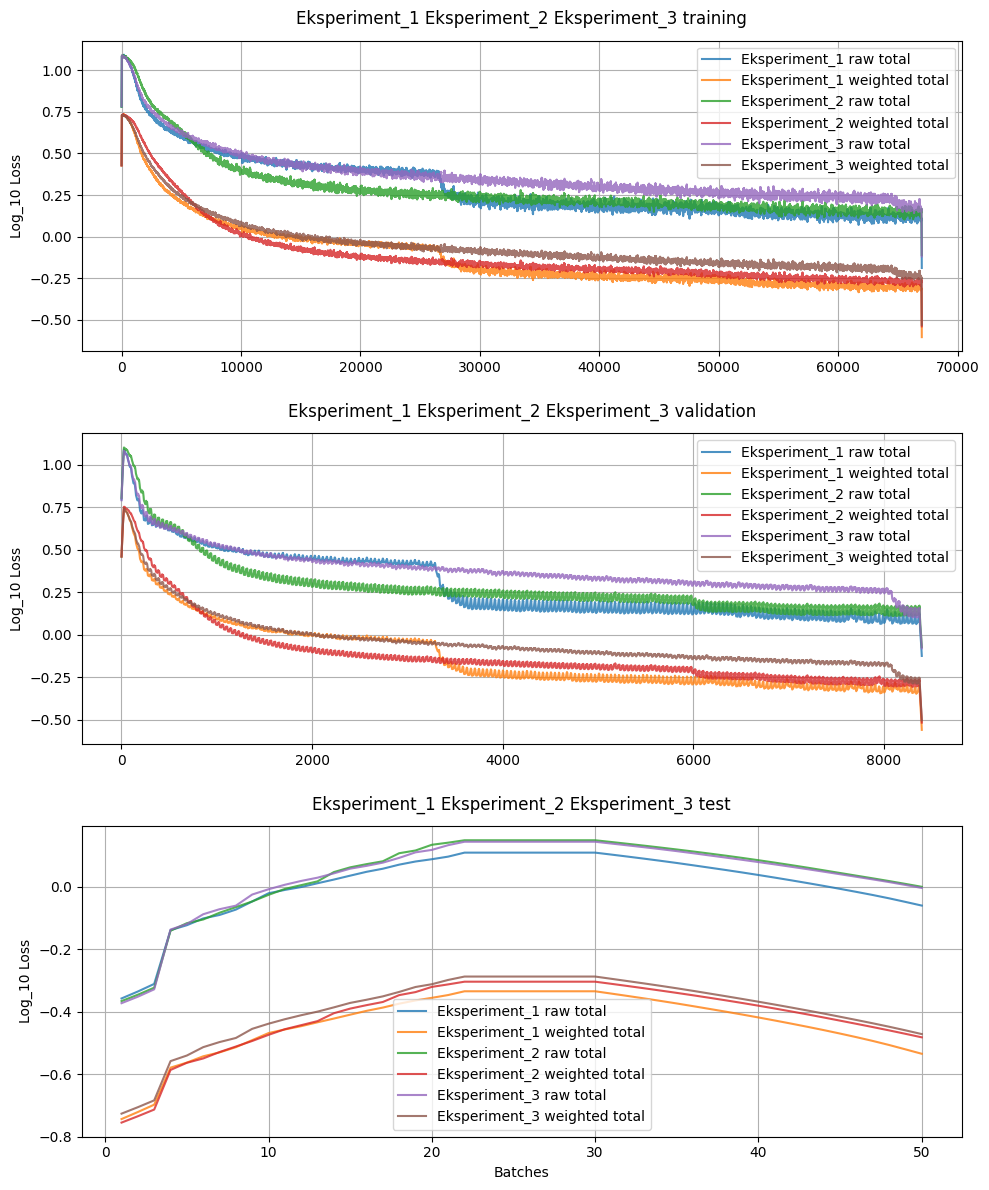

In [34]:
def plot_experiment(folder_name, losses, source="raw"):
    folder_names = [folder_name] if isinstance(folder_name, str) else list(folder_name)
    losses = [losses] if isinstance(losses, str) else list(losses)
    sources = [source] if isinstance(source, str) else list(source)
    kernel = np.ones(avg_vindue, dtype=float) / avg_vindue

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    for ax, split in zip(axes, ("training", "validation", "test")):
        for name in folder_names:
            history = experiments[name]
            for src in sources:
                for loss in losses:
                    values = np.asarray(history[split][src][loss], dtype=float)
                    values = np.convolve(values, kernel, mode="same")
                    values = np.log10(values)
                    steps = np.arange(1, len(values) + 1)
                    ax.plot(steps, values, label=f"{name} {src} {loss}", alpha=0.8)

        ax.set(title=f"{' '.join(folder_names)} {split}", ylabel="Log_10 Loss")
        ax.set_title(f"{' '.join(folder_names)} {split}", pad=12)
        # ax.set_ylim(-5.2, 1.5)
        ax.grid(True)
        ax.legend()
    axes[-1].set_xlabel("Batches")

    fig.tight_layout(h_pad=2.0)
    # plt.savefig(output_dir / f"{'_'.join(folder_names)}_{'_'.join(losses)}_{'_'.join(sources)}.png")
    plt.show()
    # return fig, axes, history


# losses = total, da, eq
# source = weighted, raw
avg_vindue = 50
output_dir = ROOT_DIR / "billeder" / "DoE" / "PINN_z"
plot_experiment(["Eksperiment_1", "Eksperiment_2", "Eksperiment_3"], losses=["total"], source=["raw", "weighted"])


In [ ]:
def reduce_history(values, reducer):
    first = values[0]
    if isinstance(first, dict):
        return {key: reduce_history([value[key] for value in values], reducer) for key in first}
    if isinstance(first, list):
        width = max(map(len, values), default=0)
        if not width:
            return []
        padded = np.full((len(values), width), np.nan)
        for index, value in enumerate(values):
            padded[index, : len(value)] = value
        return reducer(padded, axis=0).tolist()
    return float(reducer(np.asarray(values, dtype=float)))


output_dir.mkdir(parents=True, exist_ok=True)
y_limits = {"training": (0, 25), "validation": (0, 10), "test": (0, 35)}


def sort_key(name):
    return tuple(int(part) if part.isdigit() else part for part in name.split("_"))


grouped_histories = {}
for name, history in experiments.items():
    parts = name.split("_")
    group_name = "_".join(parts[:-1]) if len(parts) > 2 else name
    grouped_histories.setdefault(group_name, []).append(history)

experiment_groups = {}

for group_name in sorted(grouped_histories, key=sort_key):
    histories = grouped_histories[group_name]
    avg = reduce_history(histories, np.nanmean)
    std = reduce_history(histories, np.nanstd)
    label = group_name.replace("ex_", "ex", 1)
    experiment_groups[label] = {"histories": histories, "avg": avg, "std": std}
    globals()[f"{label}_avg"], globals()[f"{label}_std"] = avg, std

    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    for ax, split in zip(axes, ("training", "validation", "test")):
        values = np.asarray(avg[split]["raw"]["total"], dtype=float)
        std_values = np.asarray(std[split]["raw"]["total"], dtype=float)
        epochs = np.arange(1, len(values) + 1)
        ax.plot(epochs, values, label=f"{split} raw total mean", alpha=0.8)
        ax.fill_between(
            epochs,
            values - std_values,
            values + std_values,
            alpha=0.3,
            color="red",
            label=f"{split} raw total std",
        )
        ax.set(title=f"{label}_avg {split}", xlabel="Step", ylabel="Loss")
        ax.set_ylim(*y_limits[split])
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.tight_layout()
    path = output_dir / f"{label}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {path}")
    plt.show()


In [ ]:
selected_experiments = ["ex9", "ex10", "ex11", "ex12"]
save_overlap_plot = True
overlap_window = 3

selected_data = {name: experiment_groups[name] for name in selected_experiments}
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for ax, split in zip(axes, ("training", "validation", "test")):
    for name, data in selected_data.items():
        values = np.asarray(data["avg"][split]["raw"]["total"], dtype=float)
        std_values = np.asarray(data["std"][split]["raw"]["total"], dtype=float)
        values = moving_average(values, overlap_window)
        std_values = moving_average(std_values, overlap_window)
        epochs = np.arange(1, len(values) + 1)
        line, = ax.plot(epochs, values, label=f"{name} avg")
        ax.fill_between(epochs, values - std_values, values + std_values, alpha=0.15, color=line.get_color(), label=f"{name} std")
    ax.set(title=f"Overlap {split}", xlabel="Step", ylabel="Loss")
    ax.set_ylim(*y_limits[split])
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
if save_overlap_plot:
    overlap_name = "_".join(selected_experiments)
    save_figure(fig, output_dir / f"overlap_{overlap_name}.png")
plt.show()
